In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("Data.csv")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [3]:
X = df.iloc[:,:4]
y = df.iloc[:,4]

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [5]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred = regressor.predict(X_test)

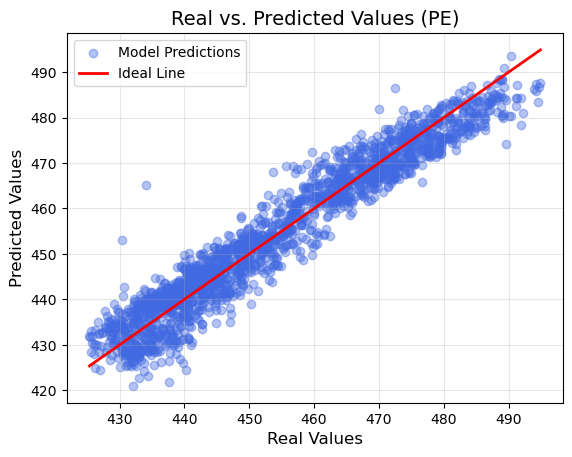

In [7]:
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.4, label='Model Predictions')
ideal_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(ideal_line, ideal_line, color='red', linewidth=2, linestyle='-', label='Ideal Line')
plt.title('Real vs. Predicted Values (PE)', fontsize=14)
plt.xlabel('Real Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Text(0.5, 0.98, 'Multiple Linear Regression')

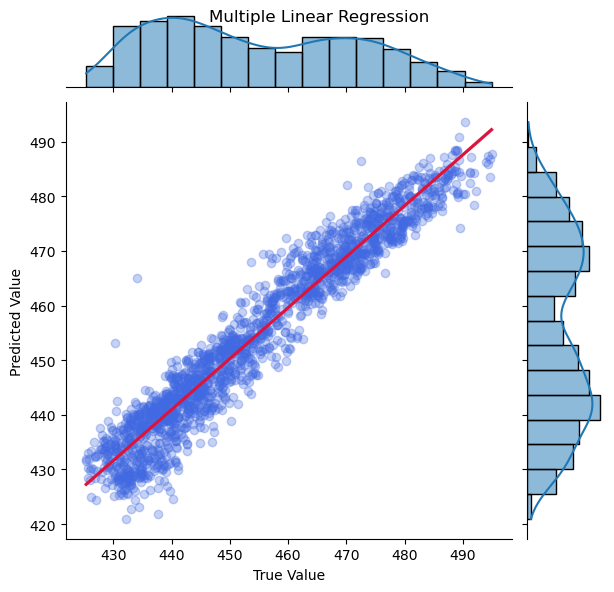

In [8]:
import seaborn as sns
g = sns.jointplot(x=y_test, y=y_pred, kind="reg", scatter_kws={'alpha':0.3, 'color': 'royalblue'}, line_kws={'color': 'crimson'})
g.set_axis_labels("True Value", "Predicted Value")
g.figure.suptitle("Multiple Linear Regression")

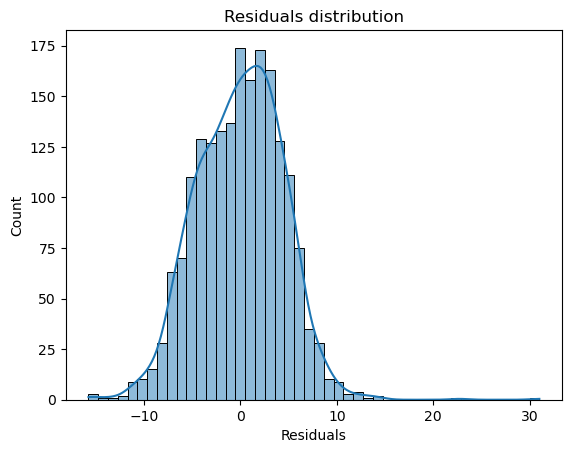

In [9]:
residuals = y_pred - y_test
plt.figure()
sns.histplot(residuals, kde=True)
plt.title('Residuals distribution')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.show()

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

print(f"r2_score: {r2_score(y_test, y_pred)}")
print(f"mean_absolute_error: {mean_absolute_error(y_test, y_pred)}")
print(f"mean_squared_error: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

y_test_mean = y_test.mean()
relative_mae = mean_absolute_error(y_test, y_pred) / y_test_mean
print(f"relative_mae: {relative_mae}({relative_mae * 100:.2f}%)")

r2_score: 0.9325315554761303
mean_absolute_error: 3.566564655203823
mean_squared_error: 19.733699303497644
RMSE: 4.44226285844249
relative_mae: 0.007845286369256674(0.78%)
